# Linear Regression - Refresher
### Predicting Chicago taxi fares

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Environment ready.")

Environment ready.


In [60]:
CSV_PATH = "chicago_taxi_train.csv"

full_df = pd.read_csv(CSV_PATH)
full_df.columns

Index(['TRIP_START_TIMESTAMP', 'TRIP_END_TIMESTAMP', 'TRIP_START_HOUR',
       'TRIP_SECONDS', 'TRIP_MILES', 'TRIP_SPEED', 'PICKUP_CENSUS_TRACT',
       'DROPOFF_CENSUS_TRACT', 'PICKUP_COMMUNITY_AREA',
       'DROPOFF_COMMUNITY_AREA', 'FARE', 'TIPS', 'TIP_RATE', 'TOLLS', 'EXTRAS',
       'TRIP_TOTAL', 'PAYMENT_TYPE', 'COMPANY'],
      dtype='str')

In [61]:
df = full_df[['FARE', 'TRIP_MILES', 'TRIP_SECONDS', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE']]
df.head()

,FARE,TRIP_MILES,TRIP_SECONDS,COMPANY,PAYMENT_TYPE,TIP_RATE
0,31.99,2.57,2341,Flash Cab,Mobile,6.3
1,9.75,1.18,1074,Flash Cab,Credit Card,27.9
2,10.25,1.29,1173,Sun Taxi,Cash,0.0
3,23.75,3.70,3360,Choice Taxi Association,Cash,0.0
4,10.00,1.15,1044,Flash Cab,Cash,0.0


In [62]:
df.describe(include='all')

,FARE,TRIP_MILES,TRIP_SECONDS,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,23.905210,8.289463,1319.796397,NaN,NaN,12.965785
std,16.970022,7.265672,928.932873,NaN,NaN,15.517765
min,3.250000,0.500000,60.000000,NaN,NaN,0.000000
25%,9.000000,1.720000,548.000000,NaN,NaN,0.000000
50%,18.750000,5.920000,1081.000000,NaN,NaN,12.200000
75%,38.750000,14.500000,1888.000000,NaN,NaN,20.800000


In [63]:
df.isnull().sum()

FARE            0
TRIP_MILES      0
TRIP_SECONDS    0
COMPANY         0
PAYMENT_TYPE    0
TIP_RATE        0
dtype: int64

In [64]:
corr_mat = df.corr(numeric_only=True)

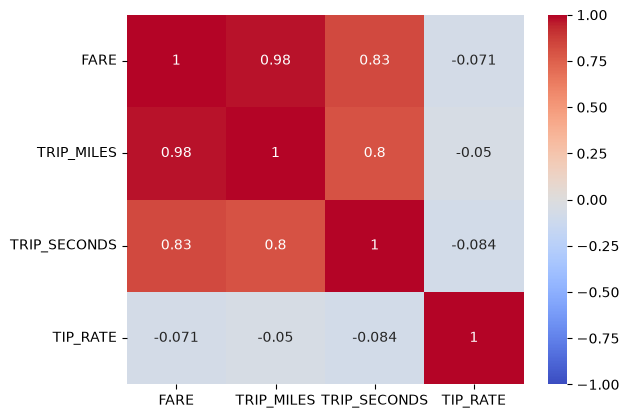

In [65]:
sns.heatmap(corr_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

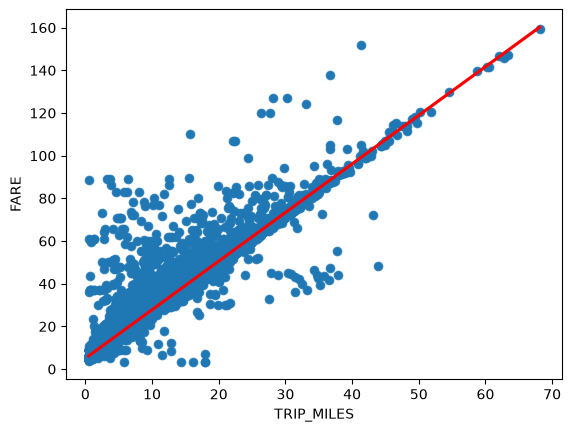

In [66]:
sns.scatterplot(data=df, x='TRIP_MILES', y='FARE')
plt.xlabel("Distance in miles")
plt.ylabel("Trip fare in $")
sns.regplot(data=df, x='TRIP_MILES', y='FARE', line_kws={'color': 'red'})
plt.show()

In [67]:
X = df[['TRIP_MILES']]
y =df['FARE']

print(X.shape, y.shape)

(31694, 1) (31694,)


In [68]:
lin = LinearRegression()
lin.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.28]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['TRIP_MILES']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.021
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [69]:
lin.predict([[5], [10], [20]])

c:\Users\oluwa\Documents\Career\Coding Projects\linear-regression-taxi\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([16.41162519, 27.80191195, 50.58248548])

In [70]:
lin.score(X, y) #R-square

0.9512968928570474

In [71]:
preds = lin.predict(X)
mse = mean_squared_error(y, preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y, preds)

print(rmse)
print(mae)

3.7450177275047274
1.5396251160032692


In [72]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])
print(X_scaled[-5:])

[[-0.7872022 ]
 [-0.97851582]
 [-0.96337589]
 [-0.63167387]
 [-0.98264489]]
[[0.65659621]
 [3.11201696]
 [0.53960587]
 [3.8965404 ]
 [3.91030397]]


In [73]:
sgd = SGDRegressor(loss="squared_error", learning_rate="constant", eta0=0.01, max_iter=1000, tol=1e-6, random_state=0) 
sgd.fit(X_scaled, y)

,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",1e-06
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"learning_rate learning_rate: str, default='invscaling'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where t0 is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if early_stopping is True, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'constant'
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0


In [74]:
feat = scaler.transform([[5], [10], [20]])
sgd.predict(feat)

c:\Users\oluwa\Documents\Career\Coding Projects\linear-regression-taxi\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([16.45197983, 27.77466045, 50.4200217 ])

In [75]:
for lr in [1.0, 0.01, 0.000001]:
    model = SGDRegressor(
        loss="squared_error",
        learning_rate="constant",
        eta0=lr,
        max_iter=1000,
        tol=1e-6,
        random_state=0,
    )
    model.fit(X_scaled, y)
    preds = model.predict(X_scaled)
    rmse = np.sqrt(mean_squared_error(y, preds))
    print(f"eta0={lr:<5}  n_iter={model.n_iter_:<5}  RMSE={rmse:.3f}")

eta0=1.0    n_iter=12     RMSE=5.094
eta0=0.01   n_iter=18     RMSE=3.746
eta0=1e-06  n_iter=280    RMSE=3.745


In [76]:
df['TRIP_MINUTES'] = df['TRIP_SECONDS'] / 60
X2 = df[['TRIP_MILES', 'TRIP_MINUTES']]

lin.fit(X2, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[2.02,0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['TRIP_MILES','TRIP_MINUTES']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.841
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [77]:
preds = lin.predict(X2)

In [78]:
mse = mean_squared_error(y, preds)
rmse = np.sqrt(mse)
rmse

np.float64(3.47604007817376)

In [79]:
lin.score(X2, y)

0.9580416439760115

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.20, random_state=0)

lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[2.03,0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['TRIP_MILES','TRIP_MINUTES']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.877
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [81]:
preds1 = lin.predict(X_train)
preds2 = lin.predict(X_test)

In [82]:
mse1 = mean_squared_error(y_train, preds1)
mse2 = mean_squared_error(y_test, preds2)

print(f"Train RMSE: {np.sqrt(mse1)}, Test RMSE: {np.sqrt(mse2)}")
print(lin.score(X_test, y_test))
print(lin.score(X_train, y_train))

Train RMSE: 3.473650842542884, Test RMSE: 3.486996664512701
0.957759775218674
0.9581028275259263


## to-do

1. **Handle a categorical feature.**
2. **Plot the loss curve.**
3. **Outlier check.** Filter extreme fares/miles and refit to see if RMSE improves
4. **Manual gradient descent.** with one feature and MSE, write the update loop in numpy; compute the two slopes. Match scikit-learn answer.